In [33]:
import logging
import warnings
from pathlib import Path

import torch
import torch.nn.functional as F
import hydra
import numpy as np
import SimpleITK as sitk
from tqdm import tqdm
from huggingface_hub import hf_hub_download
from monai.inferers import SlidingWindowInfererAdapt
from skimage.morphology import remove_small_objects
from skimage.exposure import equalize_hist

from vesselfm.seg.utils.data import generate_transforms
from vesselfm.seg.utils.evaluation import Evaluator, calculate_mean_metrics


warnings.filterwarnings("ignore")
logger = logging.getLogger(__name__)

In [34]:
def load_model(cfg, device):
    try:
        logger.info(f"Loading model from {cfg.ckpt_path}.")
        ckpt = torch.load(Path(cfg.ckpt_path), map_location=device, weights_only=False)
    except Exception as e:
        logger.warning(f"Failed to load model from {cfg.ckpt_path} due to {e}. Attempting to load from Hugging Face Hub.")
        logger.info(f"Loading model from Hugging Face.")
        hf_hub_download(repo_id='bwittmann/vesselFM', filename='meta.yaml') # required to track downloads
        ckpt = torch.load(
            hf_hub_download(repo_id='bwittmann/vesselFM', filename='vesselFM_base.pt'),
            map_location=device, weights_only=False
        )

    model = hydra.utils.instantiate(cfg.model)
    
    # 1. On extrait le dictionnaire des poids s'il vient de PyTorch Lightning
    state_dict = ckpt.get("state_dict", ckpt)
    
    # 2. (Optionnel mais recommandé) PyTorch Lightning ajoute souvent un préfixe 
    # "model." ou "net." aux noms des couches. On le retire pour que ça corresponde au DynUNet.
    clean_state_dict = {}
    for k, v in state_dict.items():
        # Enlève le préfixe s'il existe
        new_key = k.replace("model.", "").replace("net.", "") 
        clean_state_dict[new_key] = v

    # 3. On charge les poids nettoyés
    model.load_state_dict(clean_state_dict)
    
    return model

def write_nifti(data, file_path, spacing=None):
    meta_data = {}
    meta_data['itk_spacing'] = spacing if spacing else [1, 1, 1]
    data_itk = sitk.GetImageFromArray(data)
    data_itk.SetSpacing(meta_data['itk_spacing'])
    sitk.WriteImage(data_itk, str(file_path))

def read_nifti(path):
    sitk_img = sitk.ReadImage(path)
    orig_size = np.array(sitk_img.GetSize())
    orig_spacing = np.array(sitk_img.GetSpacing())
    print(f"Original image size: {orig_size}, spacing: {orig_spacing}, origin: {sitk_img.GetOrigin()}, direction: {sitk_img.GetDirection()}")

    if not all(s == orig_spacing[0] for s in orig_spacing):  # data needs to be isotropic
        logger.warning("Image spacing is anisotropic.")

        if len(set(orig_spacing)) != len(orig_spacing):
            duplicate = [s for s in orig_spacing if list(orig_spacing).count(s) == 2][0]
            target_spacing = [duplicate, duplicate, duplicate]
        else:
            target_spacing = [min(orig_spacing)] * 3
        target_size = np.round(orig_size * (orig_spacing / target_spacing)).astype(int)
        logger.info(f"Adjust spacing from {orig_spacing} to {target_spacing}")

        resampler = sitk.ResampleImageFilter()
        interpolator = sitk.sitkLinear
        resampler.SetInterpolator(interpolator)
        resampler.SetOutputSpacing(target_spacing)
        resampler.SetSize([int(s) for s in target_size])
        resampler.SetOutputOrigin(sitk_img.GetOrigin())
        resampler.SetOutputDirection(sitk_img.GetDirection())

        # perform resampling
        sitk_img = resampler.Execute(sitk_img)
    else:
        target_spacing = list(orig_spacing)

    img = sitk.GetArrayFromImage(sitk_img)
    return img, target_spacing

def get_paths(cfg):
    image_paths = list(Path(cfg.image_path).iterdir())
    if cfg.mask_path:
        mask_paths = [Path(cfg.mask_path) / f"{p.name}" for p in image_paths]
        assert all(
            mask_path.exists() for mask_path in mask_paths
        ), "All mask paths must exist mask name has to be the same as the image name."
    else:
        mask_paths = None
    return image_paths, mask_paths

def resample(image, factor=None, target_shape=None):
    if factor == 1:
        return image
    
    if target_shape:
        _, _, new_d, new_h, new_w = target_shape
    else:
        _, _, d, h, w = image.shape
        new_d, new_h, new_w = int(round(d / factor)), int(round(h / factor)), int(round(w / factor))
    return F.interpolate(image, size=(new_d, new_h, new_w), mode="trilinear", align_corners=False)

In [35]:
from monai.transforms import (ScaleIntensityRangePercentiles)

In [48]:
dir = Path("tests/allPostKM/Dataset100_SMH-needle/04_FILTERED/MWA20220802a___2022-08-03_MR-post-ablation___011__fl3d1-t1-tra-vibe3d-sfs-3mm-p2-km_0000.nii.gz")
img, spacing = read_nifti(dir)
img = img.astype(np.float32)
# img, spacing = read_nifti("tests/MWA20220519a/RESAMPLED/002__fl3d2-t1-vibe-dixon-tra-p4-bh-320-w.nii.gz")

Original image size: [220 205 165], spacing: [1. 1. 1.], origin: (64.42066955566406, 92.87364196777344, -108.1490249633789), direction: (-1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)


Text(0.5, 1.0, 'Histogram of Original Image')

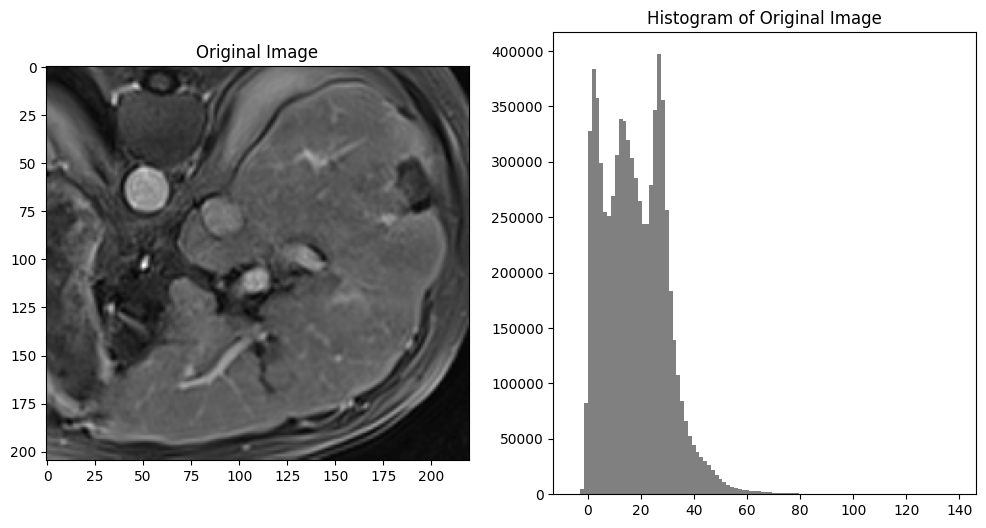

In [49]:
# histogram visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img[img.shape[0] // 2], cmap='gray')
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.hist(img.flatten(), bins=100, color='gray')
plt.title('Histogram of Original Image')

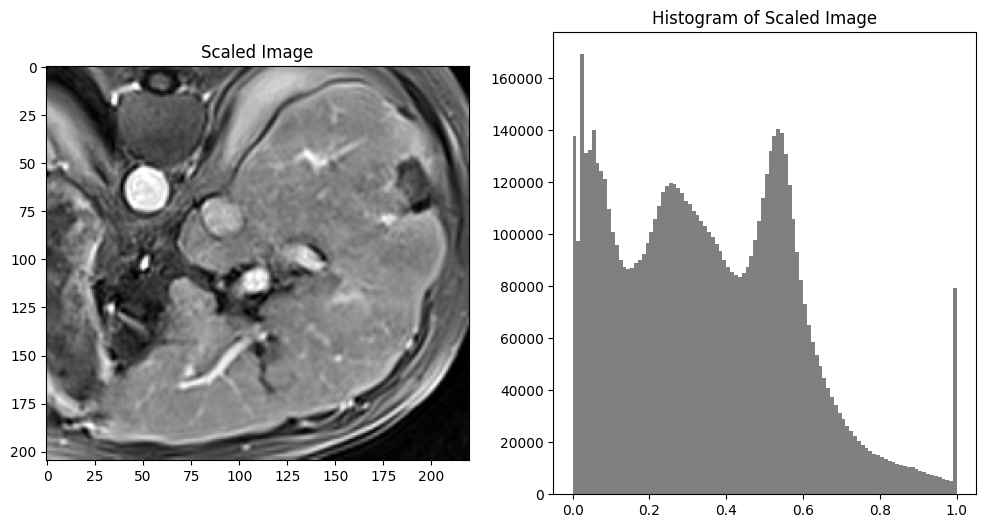

In [53]:
scaled_img = ScaleIntensityRangePercentiles(lower=1, upper=99, b_min=0.0, b_max=1.0, clip=True)(img).cpu().squeeze().numpy()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(scaled_img[scaled_img.shape[0] // 2], vmin=0, vmax=1, cmap='gray')
plt.title('Scaled Image')
plt.subplot(1, 2, 2)
plt.hist(scaled_img.flatten(), bins=100, color='gray')
plt.title('Histogram of Scaled Image')
plt.show()

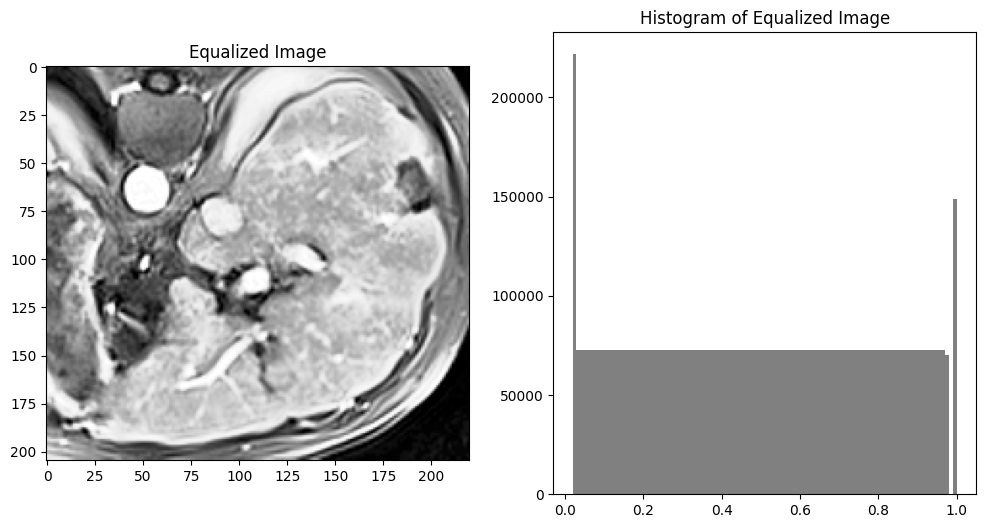

In [51]:
equalized_img = equalize_hist(scaled_img, nbins=100000)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(equalized_img[equalized_img.shape[0] // 2], cmap='gray')
plt.title('Equalized Image')
plt.subplot(1, 2, 2)
plt.hist(equalized_img.flatten(), bins=100, color='gray')
plt.title('Histogram of Equalized Image')   
plt.show()

In [52]:
write_nifti(scaled_img, dir / "RAW-NIFTI" / "007__fl3d1-axial-t1-vibe-sfs-3mm-p2-km-obb_equalized.nii.gz", spacing=spacing)

** ERROR (nifti_image_write_engine): cannot open output file 'tests/allPostKM/Dataset100_SMH-needle/04_FILTERED/MWA20220802a___2022-08-03_MR-post-ablation___011__fl3d1-t1-tra-vibe3d-sfs-3mm-p2-km_0000.nii.gz/RAW-NIFTI/007__fl3d1-axial-t1-vibe-sfs-3mm-p2-km-obb_equalized.nii.gz'


RuntimeError: Exception thrown in SimpleITK ImageFileWriter_Execute: /tmp/SimpleITK-build/ITK/Modules/IO/NIFTI/src/itkNiftiImageIO.cxx:2375:
ITK ERROR: NiftiImageIO(0x3ed986b0): ERROR: nifti library failed to write image: tests/allPostKM/Dataset100_SMH-needle/04_FILTERED/MWA20220802a___2022-08-03_MR-post-ablation___011__fl3d1-t1-tra-vibe3d-sfs-3mm-p2-km_0000.nii.gz/RAW-NIFTI/007__fl3d1-axial-t1-vibe-sfs-3mm-p2-km-obb_equalized.nii.gz

In [ ]:
spacing

[1.0, 1.0, 1.0]